<a href="https://colab.research.google.com/github/LeonardVG/cv-study-03-face-recognition-lbph/blob/main/Reconhecimento_Facial_LBPH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Estudo 03: Reconhecimento Facial com LBPH (Local Binary Patterns Histograms)

Neste notebook, implementaremos um sistema de reconhecimento facial utilizando o algoritmo **LBPH**. Diferente dos métodos Haar e HOG que apenas detectam onde está o rosto, o LBPH é capaz de identificar quem é a pessoa.

## Como o Algoritmo Funciona

O LBPH não analisa a imagem globalmente (como o Eigenfaces), mas sim localmente, analisando a textura da pele pixel a pixel.

1.  **Operador LBP:** Para cada pixel da imagem, o algoritmo olha para seus vizinhos. Se o vizinho for mais brilhante que o centro, recebe **1**, senão **0**. Isso gera um código binário que representa o padrão daquela pequena região (borda, canto, plano).
2.  **Histogramas:** A imagem é dividida em grade (grids). Para cada pedaço da grade, calcula-se um histograma dos códigos binários encontrados.
3.  **Vetor de Características:** Todos os histogramas são concatenados em um único vetor gigante que serve como a "assinatura digital" do rosto.

## ⚙️ Entendendo os Parâmetros

Ao criar o reconhecedor com `cv2.face.LBPHFaceRecognizer_create()`, podemos ajustar quatro parâmetros que alteram a sensibilidade do modelo:

### 1. Radius (Raio)
Define a distância do pixel central até seus vizinhos.
* **Valor padrão:** `1`
* **Implicação:**
    * **Raio Curto (1):** Captura texturas muito finas (poros, linhas finas). É muito detalhista.
    * **Raio Longo (2+):** Captura padrões de maior escala. Pode ser útil se a imagem tiver baixa resolução, mas perde detalhes únicos da identidade.

### 2. Neighbors
Define quantos pontos ao redor do círculo (definido pelo raio) serão amostrados.
* **Valor padrão:** `8`
* **Implicação:** Quanto maior o número, mais complexo é o padrão binário gerado. Geralmente, mantém-se 8 para um custo computacional baixo. Aumentar muito pode gerar ruído.

### 3. Grid X e Grid Y
Eles definem em quantas células a imagem do rosto será fatiada horizontalmente e verticalmente.
* **Valor padrão:** `8` (resultando em uma grade 8x8 = 64 células).
* **Implicação:**
    * **Grades Altas (ex: 8x8 ou mais):** O algoritmo entende perfeitamente a "geografia" do rosto (sabe que o histograma do olho esquerdo é diferente do queixo). Isso aumenta a precisão, mas também aumenta o tamanho do vetor de características e o tempo de processamento.
    * **Grades Baixas (ex: 2x2):** O algoritmo perde a noção espacial. Ele sabe que existem texturas de "olho", mas não sabe exatamente onde elas estão. Isso diminui drasticamente a precisão.


O LBPH é robusto contra mudanças de iluminação justamente porque compara pixels vizinhos (o contraste local se mantém mesmo se a luz ambiente mudar), e a divisão em **Grids** garante que ele saiba diferenciar as partes do rosto.

---

## ⚠️ Configuração do Ambiente: Módulos Extras do OpenCV

Para utilizar algoritmos de reconhecimento facial como o **LBPH** (Local Binary Patterns Histograms) ou **EigenFaces**, o pacote padrão do OpenCV (`opencv-python`) não é suficiente, pois ele não inclui o submódulo `cv2.face`.

Esses algoritmos residem no pacote **opencv-contrib**, que contém módulos em desenvolvimento ou patenteados.

**Instruções de Execução:**
1.  Execute as duas células de código abaixo para substituir a versão padrão pela versão `contrib-headless`.
2.  Após a instalação, você deve reiniciar o ambiente para que o Python carregue a nova biblioteca.
    * *Menu Superior > Ambiente de Execução > Reiniciar sessão* (ou `Ctrl + M + .`)

In [6]:
!pip uninstall opencv-python -y
!pip uninstall opencv-contrib-python -y
!pip uninstall opencv-contrib-python-headless -y

Found existing installation: opencv-contrib-python 4.12.0.88
Uninstalling opencv-contrib-python-4.12.0.88:
  Successfully uninstalled opencv-contrib-python-4.12.0.88


In [7]:
# Instala a versão correta
!pip install opencv-contrib-python-headless

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.8/68.8 MB 12.3 MB/s eta 0:00:00


In [1]:
import cv2

# Verifica a versão instalada
print(f"Versão do OpenCV: {cv2.__version__}")

# Verifica se o módulo 'face' está disponível dentro do cv2
try:
    print(dir(cv2.face))
    recognizer = cv2.face.LBPHFaceRecognizer_create()
    print("Sucesso! Reconhecedor criado.")
except AttributeError:
    print("Erro: O módulo 'face' ainda não foi carregado corretamente.")
except Exception as e:
    print(f"Outro erro ocorreu: {e}")

Versão do OpenCV: 4.12.0
['BIF', 'BIF_create', 'BasicFaceRecognizer', 'EigenFaceRecognizer', 'EigenFaceRecognizer_create', 'FaceRecognizer', 'Facemark', 'FacemarkAAM', 'FacemarkKazemi', 'FacemarkLBF', 'FacemarkTrain', 'FisherFaceRecognizer', 'FisherFaceRecognizer_create', 'LBPHFaceRecognizer', 'LBPHFaceRecognizer_create', 'MACE', 'MACE_create', 'MACE_load', 'PredictCollector', 'StandardCollector', 'StandardCollector_create', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '_native', 'createFacemarkAAM', 'createFacemarkKazemi', 'createFacemarkLBF', 'drawFacemarks', 'getFacesHAAR', 'loadDatasetList', 'loadFacePoints', 'loadTrainingData']
Sucesso! Reconhecedor criado.


##Carregamento da Base de dados
* Yale faces database: http://vision.ucsd.edu/content/yale-face-database

Importando Bibliotecas e Montando o drive

In [28]:
from PIL import Image   # Para processamento digital de imagens, necessário para lidar com a base de dados
import numpy as np
import zipfile
import os
import time
from google.colab.patches import cv2_imshow

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
path = '/content/drive/MyDrive/Colab Notebooks/Visao_Computacional/Curso-GuiaCompleto/Datasets/yalefaces.zip'
zip_object = zipfile.ZipFile(file=path, mode='r')
zip_object.extractall('./')
zip_object.close()

##Pré-processamento de imagens

como listar as imagens de uma pasta:

In [3]:
print(os.listdir('/content/yalefaces/train'))

['subject07.glasses.gif', 'subject14.leftlight.gif', 'subject11.sad.gif', 'subject05.happy.gif', 'subject04.wink.gif', 'subject07.centerlight.gif', 'subject08.noglasses.gif', 'subject11.rightlight.gif', 'subject08.sad.gif', 'subject07.wink.gif', 'subject05.wink.gif', 'subject14.glasses.gif', 'subject06.wink.gif', 'subject12.glasses.gif', 'subject12.wink.gif', 'subject01.surprised.gif', 'subject14.wink.gif', 'subject05.sad.gif', 'subject14.surprised.gif', 'subject02.rightlight.gif', 'subject03.rightlight.gif', 'subject14.rightlight.gif', 'subject05.noglasses.gif', 'subject13.surprised.gif', 'subject12.noglasses.gif', 'subject08.centerlight.gif', 'subject09.happy.gif', 'subject09.glasses.gif', 'subject02.sleepy.gif', 'subject13.glasses.gif', 'subject15.wink.gif', 'subject14.sleepy.gif', 'subject10.surprised.gif', 'subject09.noglasses.gif', 'subject12.leftlight.gif', 'subject12.sad.gif', 'subject04.sleepy.gif', 'subject12.sleepy.gif', 'subject13.noglasses.gif', 'subject01.glasses.gif', 's

como obter o caminho completo para cada imagem:

In [7]:
paths = [os.path.join('/content/yalefaces/train', f) for f in os.listdir('/content/yalefaces/train')]
print(paths)
print(f"total de imagens:",str(len(paths)))

['/content/yalefaces/train/subject07.glasses.gif', '/content/yalefaces/train/subject14.leftlight.gif', '/content/yalefaces/train/subject11.sad.gif', '/content/yalefaces/train/subject05.happy.gif', '/content/yalefaces/train/subject04.wink.gif', '/content/yalefaces/train/subject07.centerlight.gif', '/content/yalefaces/train/subject08.noglasses.gif', '/content/yalefaces/train/subject11.rightlight.gif', '/content/yalefaces/train/subject08.sad.gif', '/content/yalefaces/train/subject07.wink.gif', '/content/yalefaces/train/subject05.wink.gif', '/content/yalefaces/train/subject14.glasses.gif', '/content/yalefaces/train/subject06.wink.gif', '/content/yalefaces/train/subject12.glasses.gif', '/content/yalefaces/train/subject12.wink.gif', '/content/yalefaces/train/subject01.surprised.gif', '/content/yalefaces/train/subject14.wink.gif', '/content/yalefaces/train/subject05.sad.gif', '/content/yalefaces/train/subject14.surprised.gif', '/content/yalefaces/train/subject02.rightlight.gif', '/content/yal

como utilizar `Image`

In [21]:
path = paths[0]
imagem = Image.open(path)
print(f"imagem do tipo: {type(imagem)}")
imagem_np = np.array(imagem, 'uint8')
print(f"imagem_np do tipo: {type(imagem_np)}")
imagem_np.shape   #As imagens da base de dados já estão em escala de cinza, mas como boa prática vamos convertelas na proxima célula


imagem do tipo: <class 'PIL.GifImagePlugin.GifImageFile'>
imagem_np do tipo: <class 'numpy.ndarray'>


(243, 320)

In [25]:
for path in paths:
  imagem = Image.open(path).convert('L') #gray
  print(f"imagem do tipo: {type(imagem)}")
  imagem_np = np.array(imagem, 'uint8')
  print(f"imagem_np do tipo: {type(imagem_np)}")
  print(f"Dimensão da imagem: {imagem_np.shape}")
  print("-----------------------------")

imagem do tipo: <class 'PIL.Image.Image'>
imagem_np do tipo: <class 'numpy.ndarray'>
Dimensão da imagem: (243, 320)
-----------------------------
imagem do tipo: <class 'PIL.Image.Image'>
imagem_np do tipo: <class 'numpy.ndarray'>
Dimensão da imagem: (243, 320)
-----------------------------
imagem do tipo: <class 'PIL.Image.Image'>
imagem_np do tipo: <class 'numpy.ndarray'>
Dimensão da imagem: (243, 320)
-----------------------------
imagem do tipo: <class 'PIL.Image.Image'>
imagem_np do tipo: <class 'numpy.ndarray'>
Dimensão da imagem: (243, 320)
-----------------------------
imagem do tipo: <class 'PIL.Image.Image'>
imagem_np do tipo: <class 'numpy.ndarray'>
Dimensão da imagem: (243, 320)
-----------------------------
imagem do tipo: <class 'PIL.Image.Image'>
imagem_np do tipo: <class 'numpy.ndarray'>
Dimensão da imagem: (243, 320)
-----------------------------
imagem do tipo: <class 'PIL.Image.Image'>
imagem_np do tipo: <class 'numpy.ndarray'>
Dimensão da imagem: (243, 320)
--------

Como pegar somente o id de cada pessoa da base de dados:

usamos `split`

In [46]:
#primeiro quebramos o caminho até o ponto:
#Exemplo em apenas uma imagem
path = paths[0]
imagem = Image.open(path).convert('L')
imagem_np = np.array(imagem, 'uint8')

print("caminho inteiro: " + path)
print("Usando Split, divide em 2 caminhos, retornando um vetor: " + str(os.path.split(path)))
print("primeira parte do caminho: " + os.path.split(path)[0])
print("segunda parte do caminho: " +os.path.split(path)[1])

print("separando a segunda parte pelo ponto: " + os.path.split(path)[1].split('.')[0])
print("usando replace para substituir o nome e ficar apenas com o número: " + os.path.split(path)[1].split('.')[0].replace('subject', ''))

caminho inteiro: /content/yalefaces/train/subject07.glasses.gif
Usando Split, divide em 2 caminhos, retornando um vetor: ('/content/yalefaces/train', 'subject07.glasses.gif')
primeira parte do caminho: /content/yalefaces/train
segunda parte do caminho: subject07.glasses.gif
separando a segunda parte pelo ponto: subject07
usando replace para substituir o nome e ficar apenas com o número: 07


Juntando tudo e criando uma função:

In [4]:
def get_image_data():
  paths = [os.path.join('/content/yalefaces/train', f) for f in os.listdir('/content/yalefaces/train')]
  faces = []
  ids = []
  for path in paths:
    imagem = Image.open(path).convert('L')
    imagem_np = np.array(imagem, 'uint8')

    id = int(os.path.split(path)[1].split('.')[0].replace('subject', ''))

    ids.append(id)
    faces.append(imagem_np)

  return np.array(ids), faces

In [5]:
ids, faces = get_image_data()
print(f"total ids: {len(ids)}")
print(f"total faces: {len(faces)}")

total ids: 135
total faces: 135


In [56]:
ids

array([ 7, 14, 11,  5,  4,  7,  8, 11,  8,  7,  5, 14,  6, 12, 12,  1, 14,
        5, 14,  2,  3, 14,  5, 13, 12,  8,  9,  9,  2, 13, 15, 14, 10,  9,
       12, 12,  4, 12, 13,  1, 11,  2, 10,  8,  5, 15,  1,  8,  4, 10,  3,
       13,  2,  9,  7,  4,  6,  4,  6,  6,  2, 11, 11,  4, 15,  6,  6,  5,
        1,  4, 15,  5,  4,  3,  5,  5, 15, 13,  1,  7, 13,  3,  3,  3, 13,
       15,  8,  9,  7,  8,  7,  7, 12, 11,  2,  1, 10, 14,  1,  8, 12, 13,
        6, 15,  9, 11,  1, 12,  9,  4,  3,  2,  2, 10,  3,  9,  6,  6, 11,
        2, 13,  7,  1, 11,  3,  9, 15, 14, 10, 10, 10, 15, 10, 14,  8])

array([[130, 130, 130, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [ 68,  68,  68, ...,  68,  68,  68]], dtype=uint8)
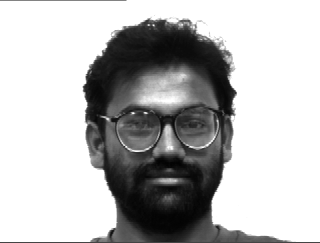

In [62]:
faces[0]

In [63]:
print(faces[0].shape)

(243, 320)


## Treinamento do classificador LBPH

In [32]:
lbph_classifier = cv2.face.LBPHFaceRecognizer_create()
inicio_train = time.time()
lbph_classifier.train(faces, ids)
fim_train = time.time()
lbph_classifier.write('lbph_classifier.yml')
print(f"Tempo de treino:{fim_train-inicio_train:.4f}s")

Tempo de treino:2.5191s


##Reconhecimento de Faces

In [18]:
lbph_classifier.read('/content/lbph_classifier.yml')

#pegando uma imagem da pasta teste
imagem_teste_path = '/content/yalefaces/test/subject07.happy.gif' #Pessoa 7
imagem = Image.open(imagem_teste_path).convert('L')
imagem_np = np.array(imagem, 'uint8')

#Detectando qual pessoa é --> pela imagem que importamos deve ser a pessoa 7
previsao = lbph_classifier.predict(imagem_np)
previsao

(7, 12.011750765800286)

In [19]:
saida_esperada = int(os.path.split(imagem_teste_path)[1].split('.')[0].replace('subject', ''))

print(f"Pessoa Esperada: Pessoa {saida_esperada}")
print(f"Pessoa Reconhecida: Pessoa {previsao[0]}")

Pessoa Esperada: Pessoa 7
Pessoa Reconhecida: Pessoa 7


In [22]:
def mostrar_img(imagem_np,previsao,saida_esperada):
  imagem_np = cv2.cvtColor(imagem_np, cv2.COLOR_GRAY2BGR)

  verde = (0,255,0)
  vermelho = (0,0,255)

  if previsao[0] == saida_esperada:
    cv2.putText(imagem_np, 'Pred: ' + str(previsao[0]), (10,30), cv2.FONT_HERSHEY_COMPLEX_SMALL, 1, verde)
    cv2.putText(imagem_np, 'Exp: ' + str(saida_esperada), (10,50), cv2.FONT_HERSHEY_COMPLEX_SMALL, 1, verde)
  else:
    cv2.putText(imagem_np, 'Pred: ' + str(previsao[0]), (10,30), cv2.FONT_HERSHEY_COMPLEX_SMALL, 1, vermelho)
    cv2.putText(imagem_np, 'Exp: ' + str(saida_esperada), (10,50), cv2.FONT_HERSHEY_COMPLEX_SMALL, 1, vermelho)


  cv2_imshow(imagem_np)

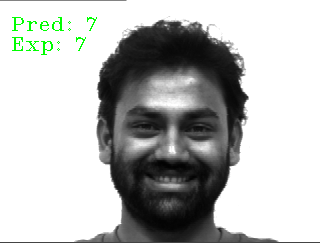

In [23]:
mostrar_img(imagem_np,previsao,saida_esperada)

##Avaliação do Classificador

In [24]:
from sklearn.metrics import accuracy_score

paths = [os.path.join('/content/yalefaces/test', f) for f in os.listdir('/content/yalefaces/test')]
previsoes = []
saidas_esperadas = []
for path in paths:
  imagem = Image.open(path).convert('L')
  imagem_np = np.array(imagem, 'uint8')
  previsao, _ = lbph_classifier.predict(imagem_np)
  saida_esperada = int(os.path.split(path)[1].split('.')[0].replace('subject', ''))

  previsoes.append(previsao)
  saidas_esperadas.append(saida_esperada)

print("accuracy:")
accuracy_score(saidas_esperadas, previsoes)

accuracy:


0.6666666666666666

## Testando os Parâmetros do classificador

Quando utilizamos o `.LBPHFaceRecognizer_create`,  os valores padrão são:
* threshold: 1.7976931348623157e+308
* radius: 1
* neighbors: 8
* grid_x: 8
* grid_y: 8

Tempo de treino:3.6691s


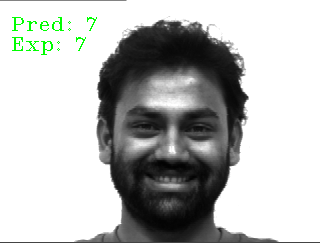

In [33]:
lbph_classifier = cv2.face.LBPHFaceRecognizer_create(radius=4, neighbors=14,grid_x=9,grid_y=9)
inicio_train = time.time()
lbph_classifier.train(faces, ids)
fim_train = time.time()
lbph_classifier.write('lbph_classifier.yml')
print(f"Tempo de treino:{fim_train-inicio_train:.4f}s")

lbph_classifier.read('/content/lbph_classifier.yml')

#pegando uma imagem da pasta teste
imagem_teste_path = '/content/yalefaces/test/subject07.happy.gif' #Pessoa 7
imagem = Image.open(imagem_teste_path).convert('L')
imagem_np = np.array(imagem, 'uint8')

previsao = lbph_classifier.predict(imagem_np)
saida_esperada = int(os.path.split(imagem_teste_path)[1].split('.')[0].replace('subject', ''))

mostrar_img(imagem_np,previsao,saida_esperada)


##Avaliação de Desempenho com parâmetros modificados

In [34]:
from sklearn.metrics import accuracy_score

paths = [os.path.join('/content/yalefaces/test', f) for f in os.listdir('/content/yalefaces/test')]
previsoes = []
saidas_esperadas = []
for path in paths:
  imagem = Image.open(path).convert('L')
  imagem_np = np.array(imagem, 'uint8')
  previsao, _ = lbph_classifier.predict(imagem_np)
  saida_esperada = int(os.path.split(path)[1].split('.')[0].replace('subject', ''))

  previsoes.append(previsao)
  saidas_esperadas.append(saida_esperada)

print("accuracy:")
accuracy_score(saidas_esperadas, previsoes)

accuracy:


0.7